In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [59]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
!ls /content/drive/MyDrive/visa_project

data  README.md  src


In [61]:
import pandas as pd

path = "/content/drive/MyDrive/visa_project/data/processed/cleaned_visa_data.csv"  # 👈 inside quotes!
df = pd.read_csv(path)

print("✅ Data loaded successfully!")
print(df.head())
print("\nColumns:", df.columns)

✅ Data loaded successfully!
  CASE_STATUS      VISA_CLASS COUNTRY_OF_CITIZENSHIP  WORK_STATE  \
0      denied            H-1B                    NaN          IL   
1      denied       greencard                   IRAN  CALIFORNIA   
2      denied            H-1B                    NaN          CA   
3      denied            H-1B                    NaN          TX   
4      denied  E-3 Australian                    NaN          OR   

  APPLICATION_DATE DECISION_DATE  processing_time_days  
0       2014-03-14    2014-03-21                     7  
1       2015-03-19    2015-03-19                     0  
2       2013-09-13    2013-09-23                    10  
3       2014-03-28    2014-04-07                    10  
4       2014-09-16    2014-09-23                     7  

Columns: Index(['CASE_STATUS', 'VISA_CLASS', 'COUNTRY_OF_CITIZENSHIP', 'WORK_STATE',
       'APPLICATION_DATE', 'DECISION_DATE', 'processing_time_days'],
      dtype='object')


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167278 entries, 0 to 167277
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   CASE_STATUS             167278 non-null  object
 1   VISA_CLASS              167278 non-null  object
 2   COUNTRY_OF_CITIZENSHIP  11093 non-null   object
 3   WORK_STATE              167278 non-null  object
 4   APPLICATION_DATE        167278 non-null  object
 5   DECISION_DATE           167278 non-null  object
 6   processing_time_days    167278 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 8.9+ MB


In [63]:
date_cols = ["APPLICATION_DATE", "DECISION_DATE"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167278 entries, 0 to 167277
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   CASE_STATUS             167278 non-null  object        
 1   VISA_CLASS              167278 non-null  object        
 2   COUNTRY_OF_CITIZENSHIP  11093 non-null   object        
 3   WORK_STATE              167278 non-null  object        
 4   APPLICATION_DATE        167278 non-null  datetime64[ns]
 5   DECISION_DATE           167278 non-null  datetime64[ns]
 6   processing_time_days    167278 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 8.9+ MB


In [65]:
df.describe()

,APPLICATION_DATE,DECISION_DATE,processing_time_days
count,167278,167278,167278.000000
mean,2013-12-31 16:31:03.723860992,2014-02-25 07:21:21.234830848,55.618258
min,2008-07-16 00:00:00,2011-10-03 00:00:00,0.000000
25%,2013-04-16 00:00:00,2013-06-11 00:00:00,6.000000
50%,2014-03-11 00:00:00,2014-03-25 00:00:00,6.000000
75%,2014-10-10 00:00:00,2014-12-17 00:00:00,7.000000
max,2015-06-29 00:00:00,2015-06-30 00:00:00,2494.000000
std,NaN,NaN,164.812881


In [66]:
df.isnull().sum()

,0
CASE_STATUS,0
VISA_CLASS,0
COUNTRY_OF_CITIZENSHIP,156185
WORK_STATE,0
APPLICATION_DATE,0
DECISION_DATE,0
processing_time_days,0


Observation:
Some categorical columns contain missing values. These are not removed
at this stage, as the objective of EDA is to understand the data rather
than modify it.

In [68]:
print(df["processing_time_days"].describe())

count    167278.000000
mean         55.618258
std         164.812881
min           0.000000
25%           6.000000
50%           6.000000
75%           7.000000
max        2494.000000
Name: processing_time_days, dtype: float64


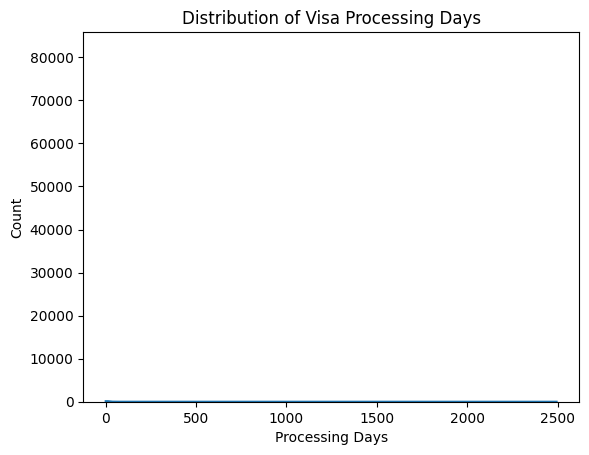

In [69]:
sns.histplot(df["processing_time_days"], kde=True)
plt.title("Distribution of Visa Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Count")
plt.show()

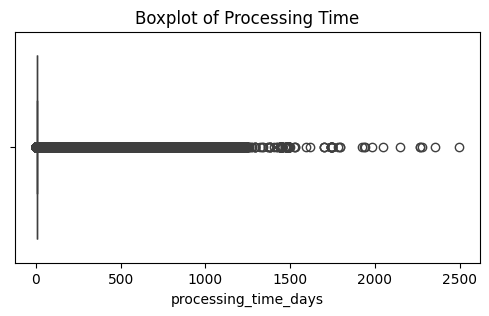

In [70]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df["processing_time_days"])
plt.title("Boxplot of Processing Time")
plt.show()

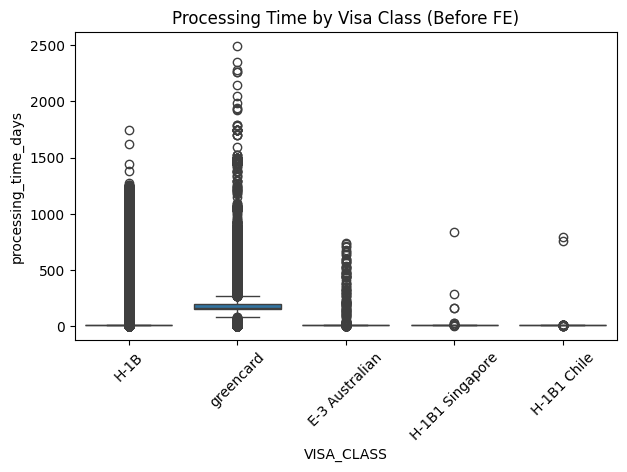

In [71]:
plt.figure(figsize=(7,4))
sns.boxplot(
    x="VISA_CLASS",
    y="processing_time_days",
    data=df
)
plt.xticks(rotation=45)
plt.title("Processing Time by Visa Class (Before FE)")
plt.show()

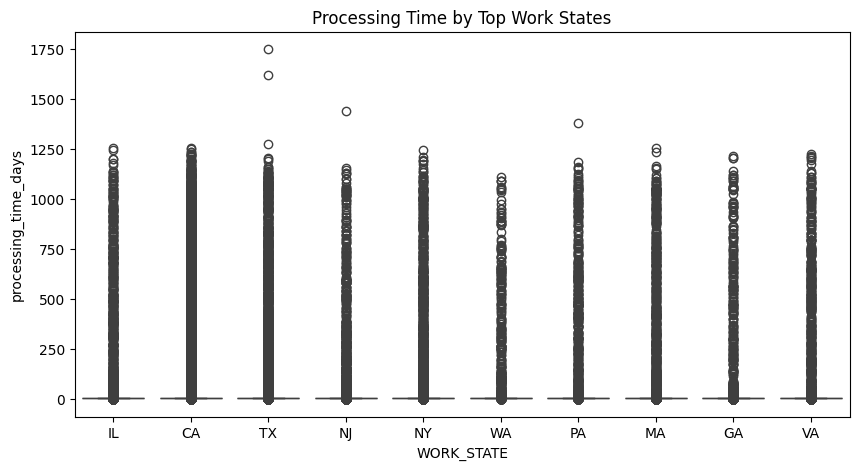

In [72]:
top_states = df["WORK_STATE"].value_counts().head(10).index
state_df = df[df["WORK_STATE"].isin(top_states)]

plt.figure(figsize=(10, 5))
sns.boxplot(x="WORK_STATE", y="processing_time_days", data=state_df)
plt.title("Processing Time by Top Work States")
plt.show()

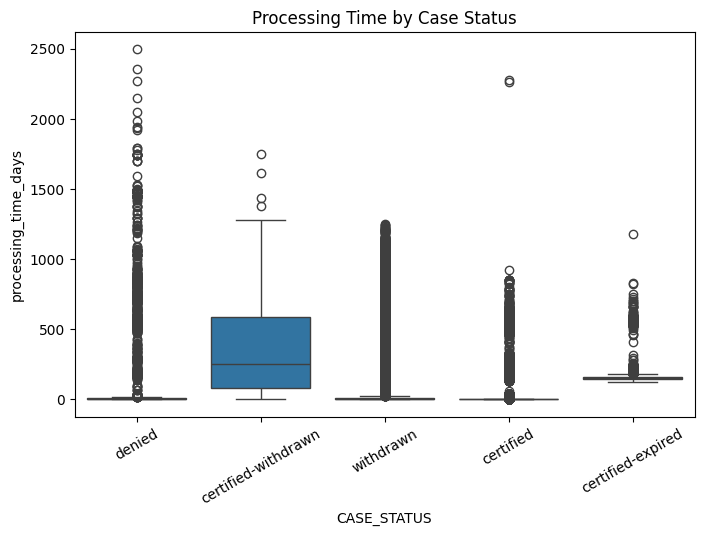

In [73]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="CASE_STATUS", y="processing_time_days", data=df)
plt.xticks(rotation=30)
plt.title("Processing Time by Case Status")
plt.show()

 Key Observations
 Visa processing time shows a right-skewed distribution, indicating
 the presence of applications with unusually long delays.Certain visa classes exhibit higher median processing times and
  greater variability.
 Processing time varies significantly across work states, suggesting
 regional differences.
 Case status appears to influence processing duration, with some
 statuses associated with longer timelines.

These insights motivate feature selection and modeling decisions
in the next milestone.

In [75]:
df["COUNTRY_OF_CITIZENSHIP"].isna().sum()

np.int64(156185)

In [76]:
df[df["COUNTRY_OF_CITIZENSHIP"].isna()].head()

,CASE_STATUS,VISA_CLASS,COUNTRY_OF_CITIZENSHIP,WORK_STATE,APPLICATION_DATE,DECISION_DATE,processing_time_days
0,denied,H-1B,NaN,IL,2014-03-14,2014-03-21,7
2,denied,H-1B,NaN,CA,2013-09-13,2013-09-23,10
3,denied,H-1B,NaN,TX,2014-03-28,2014-04-07,10
4,denied,E-3 Australian,NaN,OR,2014-09-16,2014-09-23,7
5,denied,H-1B,NaN,CA,2014-04-02,2014-04-09,7


In [77]:
df["COUNTRY_OF_CITIZENSHIP"].unique()[:20]

array([nan, 'IRAN', 'INDIA', 'FRANCE', 'JAPAN', 'TURKEY', 'CHINA',
       'CHILE', 'AUSTRALIA', 'LEBANON', 'CANADA', 'GERMANY', 'SYRIA',
       'PHILIPPINES', 'ISRAEL', 'SINGAPORE', 'ARGENTINA', 'HONG KONG',
       'MALAYSIA', 'RUSSIA'], dtype=object)

Feature 1: Application Month

In [78]:
df["application_month"] = df["APPLICATION_DATE"].dt.month
print(df)

                CASE_STATUS      VISA_CLASS COUNTRY_OF_CITIZENSHIP  \
0                    denied            H-1B                    NaN   
1                    denied       greencard                   IRAN   
2                    denied            H-1B                    NaN   
3                    denied            H-1B                    NaN   
4                    denied  E-3 Australian                    NaN   
...                     ...             ...                    ...   
167273  certified-withdrawn            H-1B                    NaN   
167274               denied            H-1B                    NaN   
167275            certified            H-1B                    NaN   
167276               denied            H-1B                    NaN   
167277               denied            H-1B                    NaN   

        WORK_STATE APPLICATION_DATE DECISION_DATE  processing_time_days  \
0               IL       2014-03-14    2014-03-21                     7   
1       C

In [79]:
corr_matrix = df[["processing_time_days", "application_month"]].corr() # calculates the correlation values
print(corr_matrix)

                      processing_time_days  application_month
processing_time_days              1.000000           0.077677
application_month                 0.077677           1.000000


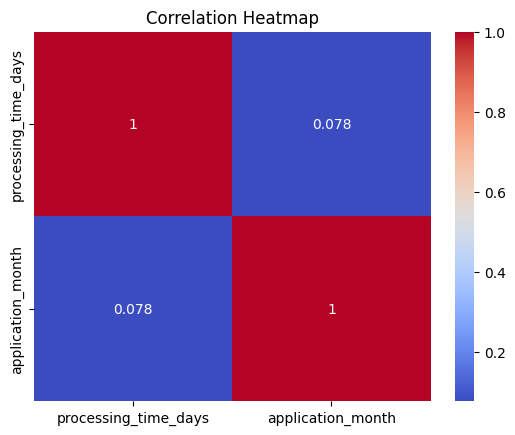

In [80]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm") # annot- shows nos inside the boxes, cmap- color scale for strnegth
plt.title("Correlation Heatmap")
plt.show()

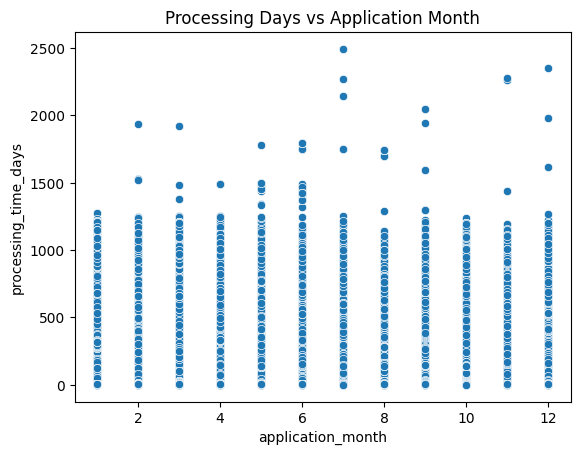

In [81]:
sns.scatterplot(
    x="application_month",
    y="processing_time_days",
    data=df
)
plt.title("Processing Days vs Application Month")
plt.show()

In [82]:

print(df[["APPLICATION_DATE", "application_month"]])

       APPLICATION_DATE  application_month
0            2014-03-14                  3
1            2015-03-19                  3
2            2013-09-13                  9
3            2014-03-28                  3
4            2014-09-16                  9
...                 ...                ...
167273       2012-08-28                  8
167274       2011-11-01                 11
167275       2011-11-09                 11
167276       2011-11-08                 11
167277       2011-10-24                 10

[167278 rows x 2 columns]


In [83]:
df["APPLICATION_DATE"].dt.year.value_counts()

,count
APPLICATION_DATE,
2014,67339
2013,49026
2015,31269
2012,9594
2011,8957
2010,981
2009,107
2008,5


In [84]:
df["application_year"] = df["APPLICATION_DATE"].dt.year

In [85]:
df["application_year"].head()

,application_year
0,2014
1,2015
2,2013
3,2014
4,2014


In [86]:
df.groupby("application_year")["processing_time_days"].mean()

,processing_time_days
application_year,
2008,2331.400000
2009,1001.794393
2010,913.425076
2011,194.607681
2012,197.451324
2013,45.098519
2014,33.329259
2015,6.267677


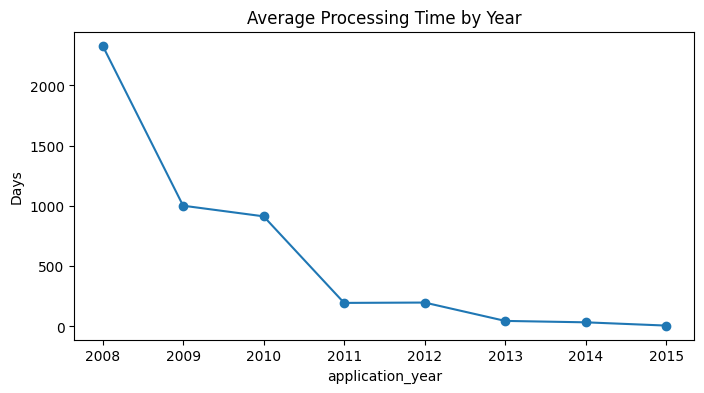

In [87]:
import matplotlib.pyplot as plt

yearly_avg = df.groupby("application_year")["processing_time_days"].mean()

plt.figure(figsize=(8,4))
yearly_avg.plot(marker='o')
plt.title("Average Processing Time by Year")
plt.ylabel("Days")
plt.show()

#This shows MASSIVE downward trend.
#If you keep raw year values:
#Model may overfit small years
#Noise from 5-row year (2008)

Feature 2: years_since_start

In [88]:
df["years_since_start"] = (
    df["application_year"] - df["application_year"].min()
)
print(df)

                CASE_STATUS      VISA_CLASS COUNTRY_OF_CITIZENSHIP  \
0                    denied            H-1B                    NaN   
1                    denied       greencard                   IRAN   
2                    denied            H-1B                    NaN   
3                    denied            H-1B                    NaN   
4                    denied  E-3 Australian                    NaN   
...                     ...             ...                    ...   
167273  certified-withdrawn            H-1B                    NaN   
167274               denied            H-1B                    NaN   
167275            certified            H-1B                    NaN   
167276               denied            H-1B                    NaN   
167277               denied            H-1B                    NaN   

        WORK_STATE APPLICATION_DATE DECISION_DATE  processing_time_days  \
0               IL       2014-03-14    2014-03-21                     7   
1       C

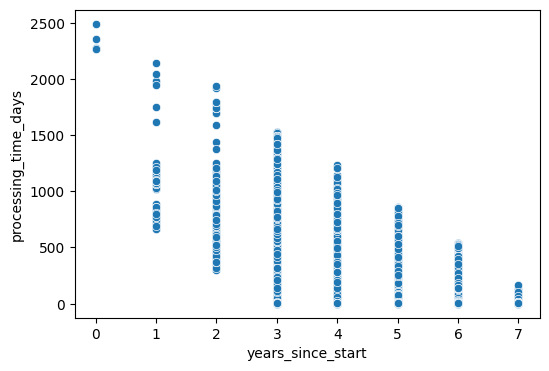

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.scatterplot(
    x="years_since_start",
    y="processing_time_days",
    data=df
)
plt.show()

 Feature 3 : Day of Week Feature

In [90]:
# 0 = Monday, 6 = Sunday
# Why this matters:
# Applications submitted on Friday may experience weekend delay.
df["application_dayofweek"] = df["APPLICATION_DATE"].dt.dayofweek
print(df)

                CASE_STATUS      VISA_CLASS COUNTRY_OF_CITIZENSHIP  \
0                    denied            H-1B                    NaN   
1                    denied       greencard                   IRAN   
2                    denied            H-1B                    NaN   
3                    denied            H-1B                    NaN   
4                    denied  E-3 Australian                    NaN   
...                     ...             ...                    ...   
167273  certified-withdrawn            H-1B                    NaN   
167274               denied            H-1B                    NaN   
167275            certified            H-1B                    NaN   
167276               denied            H-1B                    NaN   
167277               denied            H-1B                    NaN   

        WORK_STATE APPLICATION_DATE DECISION_DATE  processing_time_days  \
0               IL       2014-03-14    2014-03-21                     7   
1       C

Feature 4: Season (Peak vs Off-Peak)

In [91]:
df["season"]= df["application_month"].apply(
    lambda x: "Peak" if x in [1,2,12] else "off-peak"
) # runs the logic row by row

print(df[["application_month", "season"]])

        application_month    season
0                       3  off-peak
1                       3  off-peak
2                       9  off-peak
3                       3  off-peak
4                       9  off-peak
...                   ...       ...
167273                  8  off-peak
167274                 11  off-peak
167275                 11  off-peak
167276                 11  off-peak
167277                 10  off-peak

[167278 rows x 2 columns]


In [141]:
visa_avg = df.groupby("VISA_CLASS")["processing_time_days"].mean()
df["visa_avg_processing_time"] = df["VISA_CLASS"].map(visa_avg)
print(visa_avg)

VISA_CLASS
E-3 Australian      27.712132
H-1B                42.200593
H-1B1 Chile         16.496599
H-1B1 Singapore     15.885135
greencard          247.044713
Name: processing_time_days, dtype: float64


In [93]:
print(df)

                CASE_STATUS      VISA_CLASS COUNTRY_OF_CITIZENSHIP  \
0                    denied            H-1B                    NaN   
1                    denied       greencard                   IRAN   
2                    denied            H-1B                    NaN   
3                    denied            H-1B                    NaN   
4                    denied  E-3 Australian                    NaN   
...                     ...             ...                    ...   
167273  certified-withdrawn            H-1B                    NaN   
167274               denied            H-1B                    NaN   
167275            certified            H-1B                    NaN   
167276               denied            H-1B                    NaN   
167277               denied            H-1B                    NaN   

        WORK_STATE APPLICATION_DATE DECISION_DATE  processing_time_days  \
0               IL       2014-03-14    2014-03-21                     7   
1       C

Processing Time vs Application Month (After FE)

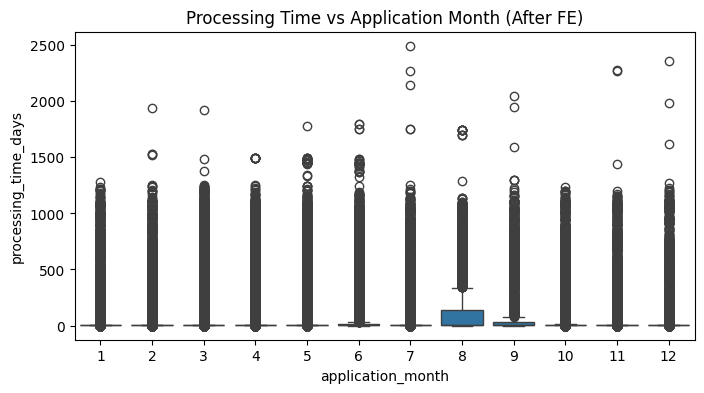

In [94]:

plt.figure(figsize=(8,4))
sns.boxplot(
    x="application_month",
    y="processing_time_days",
    data=df
)
plt.title("Processing Time vs Application Month (After FE)")
plt.show()

Processing Time vs Season (After FE)

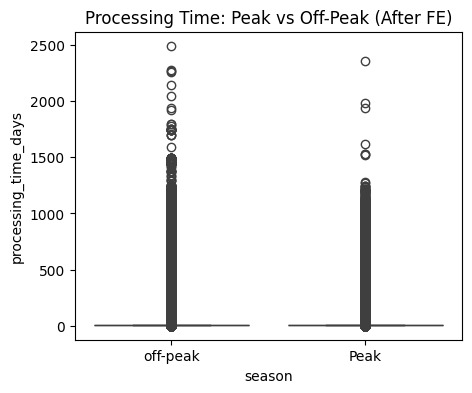

In [95]:

plt.figure(figsize=(5,4))
sns.boxplot(
    x="season",
    y="processing_time_days",
    data=df
)
plt.title("Processing Time: Peak vs Off-Peak (After FE)")
plt.show()

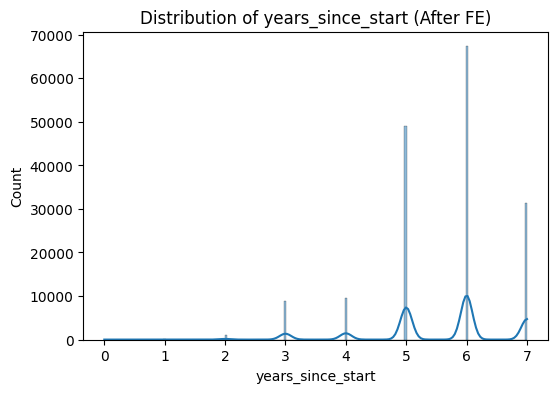

In [96]:


plt.figure(figsize=(6,4))
sns.histplot(df["years_since_start"], kde=True)
plt.title("Distribution of years_since_start (After FE)")
plt.show()

 Correlation Heatmap (After FE)

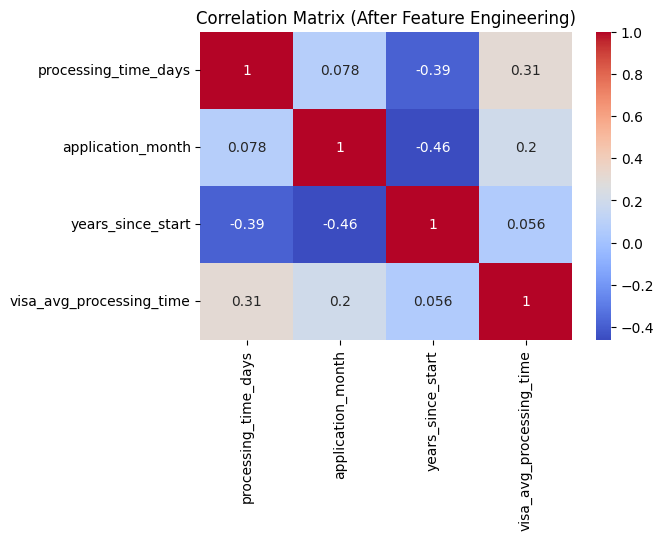

In [97]:


plt.figure(figsize=(6,4))
corr = df[
    [
        "processing_time_days",
        "application_month",
        "years_since_start",
        "visa_avg_processing_time"
    ]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (After Feature Engineering)")
plt.show()

ENCODING (Categorical → Numerical)

In [99]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "VISA_CLASS",
        "COUNTRY_OF_CITIZENSHIP",
        "WORK_STATE",
        "CASE_STATUS",
        "season"
    ],
    drop_first=True
)

SCALING (Numerical Features)

In [101]:
scaler = StandardScaler()

scale_columns = [
    "application_month",
    "years_since_start",
    "visa_avg_processing_time"
]

df_encoded[scale_columns] = scaler.fit_transform(
    df_encoded[scale_columns]
)

In [102]:
df_encoded.shape

(167278, 259)

In [103]:
df_encoded.head()

,APPLICATION_DATE,DECISION_DATE,processing_time_days,application_month,application_year,years_since_start,application_dayofweek,visa_avg_processing_time,VISA_CLASS_H-1B,VISA_CLASS_H-1B1 Chile,...,WORK_STATE_WI,WORK_STATE_WISCONSIN,WORK_STATE_WV,WORK_STATE_WY,WORK_STATE_WYOMING,CASE_STATUS_certified-expired,CASE_STATUS_certified-withdrawn,CASE_STATUS_denied,CASE_STATUS_withdrawn,season_off-peak
0,2014-03-14,2014-03-21,7,-0.721841,2014,0.383196,4,-0.262862,True,False,...,False,False,False,False,False,False,False,True,False,True
1,2015-03-19,2015-03-19,0,-0.721841,2015,1.321636,3,3.750182,False,False,...,False,False,False,False,False,False,False,True,False,True
2,2013-09-13,2013-09-23,10,1.048057,2013,-0.555245,4,-0.262862,True,False,...,False,False,False,False,False,False,False,True,False,True
3,2014-03-28,2014-04-07,10,-0.721841,2014,0.383196,4,-0.262862,True,False,...,False,False,False,False,False,False,False,True,False,True
4,2014-09-16,2014-09-23,7,1.048057,2014,0.383196,1,-0.546701,False,False,...,False,False,False,False,False,False,False,True,False,True


In [104]:
df_encoded.to_csv(
    "../content/drive/MyDrive/visa_project/data/processed/final_ml_ready_visa_data.csv",
    index=False
)

print("✅ Milestone 2 completed. Data is ML-ready.")

✅ Milestone 2 completed. Data is ML-ready.


#Milestone 3

In [122]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [123]:
df.columns

Index(['CASE_STATUS', 'VISA_CLASS', 'COUNTRY_OF_CITIZENSHIP', 'WORK_STATE',
       'APPLICATION_DATE', 'DECISION_DATE', 'processing_time_days',
       'application_month', 'application_year', 'years_since_start',
       'application_dayofweek', 'season', 'visa_avg_processing_time'],
      dtype='object')

In [124]:
X = df[
[
    "application_month",
    "application_year",
    "years_since_start",
    "application_dayofweek",
    "season",
    "visa_avg_processing_time"
]
]

y = df["processing_time_days"]

In [125]:
X = pd.get_dummies(X, columns=["season"], drop_first=True)

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [127]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [128]:
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 82.76731315962971
Linear Regression RMSE: 136.54049472963158


In [129]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [130]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 30.517299678829076
Random Forest RMSE: 87.13452085992115


In [131]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

results

,Model,MAE,RMSE
0,Linear Regression,82.767313,136.540495
1,Random Forest,30.517300,87.134521


In [133]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, None],
}

In [134]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=2,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=2, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'n_estimators': [50, 100]},
             scoring='neg_mean_absolute_error')

In [135]:
print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(X_test)

best_mae = mean_absolute_error(y_test, best_predictions)
best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

print("Tuned Random Forest MAE:", best_mae)
print("Tuned Random Forest RMSE:", best_rmse)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Tuned Random Forest MAE: 30.440597427596973
Tuned Random Forest RMSE: 86.86005909973856


Actual vs Predicted Plot (Best Model)

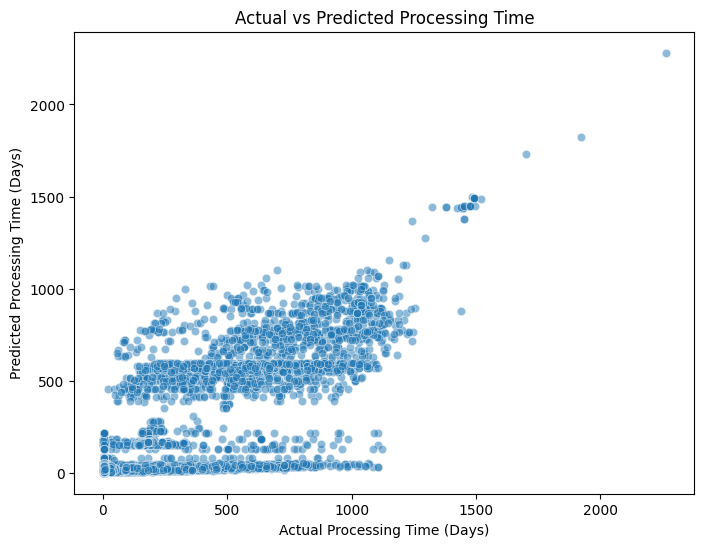

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Processing Time (Days)")
plt.ylabel("Predicted Processing Time (Days)")
plt.title("Actual vs Predicted Processing Time")

plt.show()

The scatter plot compares the actual visa processing time with the predicted values generated by the model.
Points close to the diagonal line indicate accurate predictions. The closer the data points are to this line, the better the model performs.

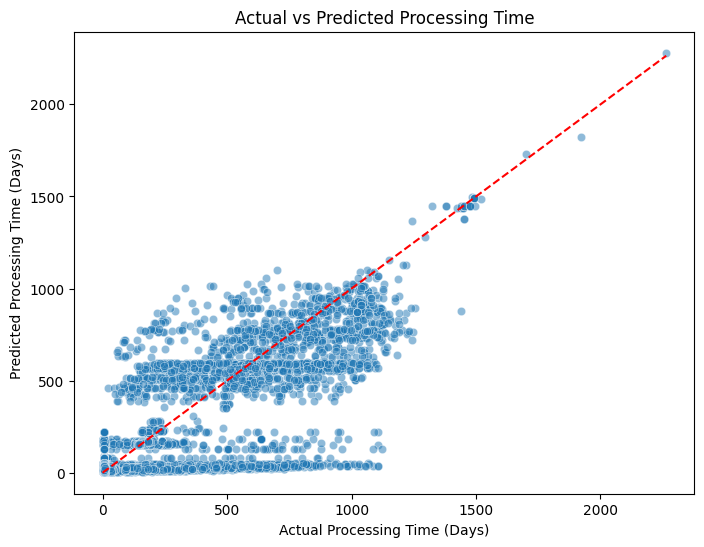

In [137]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Processing Time (Days)")
plt.ylabel("Predicted Processing Time (Days)")
plt.title("Actual vs Predicted Processing Time")

plt.show()

This shows which features influence the prediction the most.

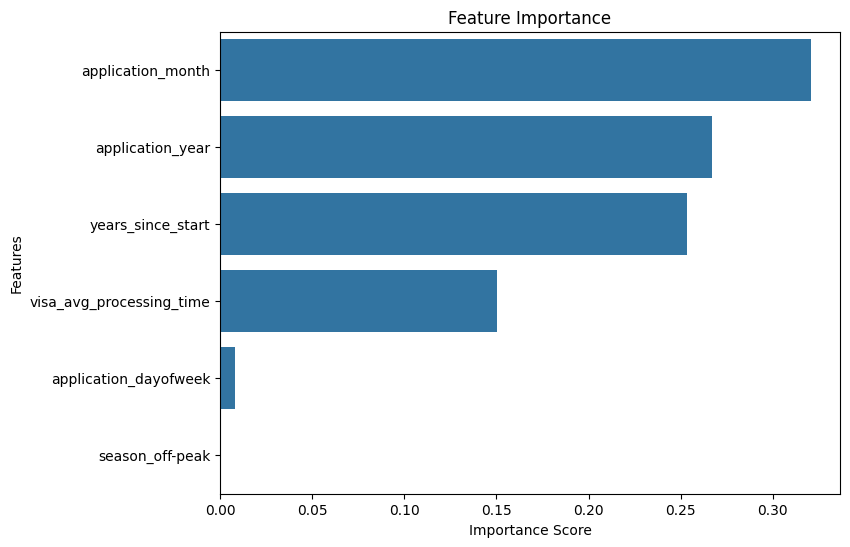

In [138]:
import pandas as pd

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=feature_importance, y=feature_importance.index)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()